In [ ]:
# 코랩에 한글화 라이브러리 설치
#!pip install koreanize-matplotlib

In [1]:
# 필수 라이브러리 임포트
!pip install koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 14.3 MB/s eta 0:00:00


## 0. 데이터 수집 및 초기 분석 (결측치/이상치 확인)
제공된 기상 데이터셋의 기본 구조와 수치적 분포를 파악하여 결측치 및 비정상 이상치가 존재하는지 점검

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# 데이터셋 로드 (코랩 파일 업로드 / 파일 경로 확인)
weather_df = pd.read_csv('/content/기상데이터셋(5년치).csv', encoding='cp949')

print('=== [0-1] 데이터셋 기본 구조 (info) ===')
print(weather_df.info())

print('\n=== [0-2] 데이터셋 수치 요약 (describe) ===')
display(weather_df.describe())

print('\n=== [0-3] 칼럼별 결측치 개수 확인 ===')
print(weather_df.isnull().sum())

=== [0-1] 데이터셋 기본 구조 (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   지점            1462 non-null   int64  
 1   지점명           1462 non-null   object 
 2   일시            1462 non-null   object 
 3   평균기온(°C)      1458 non-null   float64
 4   일강수량(mm)      614 non-null    float64
 5   평균 풍속(m/s)    1455 non-null   float64
 6   평균 이슬점온도(°C)  1456 non-null   float64
 7   평균 상대습도(%)    1459 non-null   float64
 8   평균 해면기압(hPa)  1458 non-null   float64
 9   평균 전운량(1/10)  1459 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 114.3+ KB
None

=== [0-2] 데이터셋 수치 요약 (describe) ===


,지점,평균기온(°C),일강수량(mm),평균 풍속(m/s),평균 이슬점온도(°C),평균 상대습도(%),평균 해면기압(hPa),평균 전운량(1/10)
count,1462.0,1458.000000,614.000000,1455.000000,1456.000000,1459.000000,1458.000000,1459.000000
mean,174.0,13.418313,11.190879,1.775876,8.080082,74.032557,1015.494787,5.133105
std,0.0,9.378729,24.953594,1.006671,11.167976,14.518050,7.813473,3.025213
min,174.0,-9.200000,0.000000,0.200000,-18.900000,23.900000,993.500000,0.000000
25%,174.0,5.000000,0.100000,1.100000,-1.500000,64.800000,1009.400000,2.500000
50%,174.0,13.800000,1.550000,1.400000,8.600000,76.400000,1015.500000,5.300000
75%,174.0,22.100000,10.775000,2.300000,18.625000,84.600000,1021.775000,7.800000
max,174.0,28.500000,253.700000,6.100000,25.600000,100.000000,1036.100000,10.000000



=== [0-3] 칼럼별 결측치 개수 확인 ===
지점                0
지점명               0
일시                0
평균기온(°C)          4
일강수량(mm)        848
평균 풍속(m/s)        7
평균 이슬점온도(°C)      6
평균 상대습도(%)        3
평균 해면기압(hPa)      4
평균 전운량(1/10)      3
dtype: int64


## 데이터 시각화 (EDA)
각 기상 요소 특성들의 분포와 상관관계를 시각화하여 데이터의 특성을 깊이 있게 분석

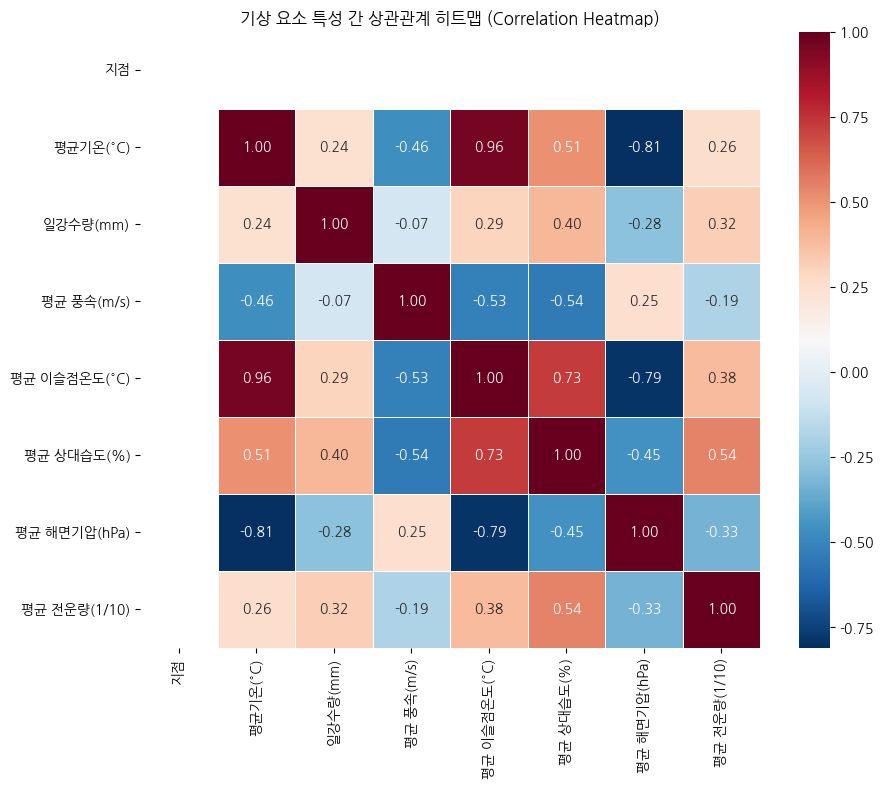

In [19]:
# 상관관계 히트맵 시각화
numeric_df = weather_df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('기상 요소 특성 간 상관관계 히트맵 (Correlation Heatmap)')
plt.show()

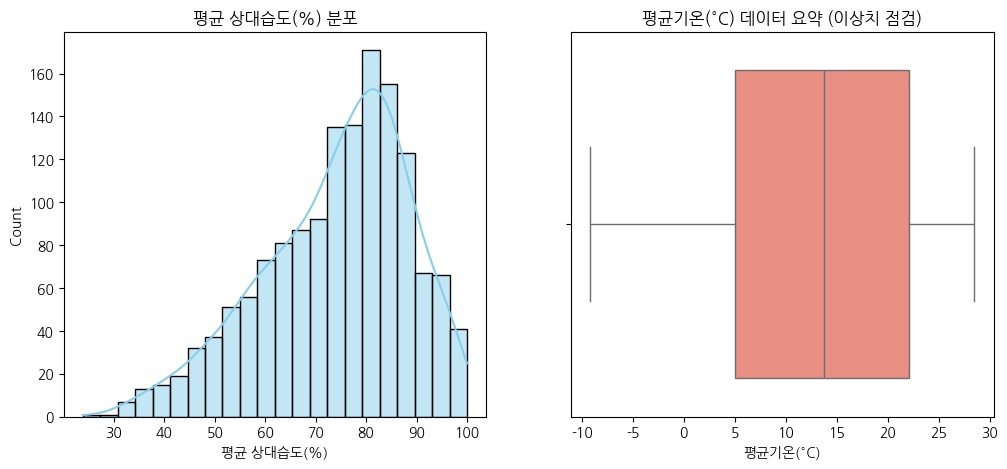

In [20]:
# 주요 기상 요소 분포 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(weather_df['평균 상대습도(%)'], kde=True, color='skyblue')
plt.title('평균 상대습도(%) 분포')

plt.subplot(1, 2, 2)
sns.boxplot(x=weather_df['평균기온(°C)'], color='salmon')
plt.title('평균기온(°C) 데이터 요약 (이상치 점검)')
plt.show()

## 1. 데이터 전처리
- `일강수량(mm)` 칼럼의 결측치(NaN)는 비가 오지 않은 맑은 날을 의미하므로 `0.0`으로 대체
- 시차 데이터 특성을 활용해 오늘의 기상 데이터와 **'내일의 강수 여부(Target_Rain)'** 정답지를 매칭

In [21]:
# 결측치 정제
weather_df['일강수량(mm)'] = weather_df['일강수량(mm)'].fillna(0.0)

# 타겟 생성: 내일(t+1)의 강수량을 오늘의 행으로 시프트하여 레이블링 수행
weather_df['내일강수량'] = weather_df['일강수량(mm)'].shift(-1)
weather_df['Target_Rain'] = weather_df['내일강수량'].apply(lambda x: 1 if x > 0 else 0)

# 마지막 행 정제 및 데이터 분리
weather_df_cleaned = weather_df.dropna(subset=['내일강수량']).copy()

selected_features = ['평균기온(°C)', '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '평균 해면기압(hPa)', '평균 전운량(1/10)', '일강수량(mm)']
X = weather_df_cleaned[selected_features]
y = weather_df_cleaned['Target_Rain']

print(f'-> 전처리 완료 후 독립변수 X 형태: {X.shape}, 타겟변수 y 형태: {y.shape}')

-> 전처리 완료 후 독립변수 X 형태: (1461, 7), 타겟변수 y 형태: (1461,)


## 2. 지도학습 모델 구축 및 성능 검증 (Model Learning & CV)

###  알고리즘 선정: 랜덤 포레스트 (Random Forest Classifier)
- **선정 사유**: 다수의 결정 트리(Decision Tree)를 앙상블하여 예측하므로 기상 데이터 내의 비선형적인 관계를 강건하게 학습. 특성 스케일이나 이상치에 강하며 과적합을 방지하는 성능이 탁월

In [25]:
# 학습 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 특성 스케일링 (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델 객체 생성 및 학습
rain_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rain_model.fit(X_train_scaled, y_train)

# 필수요구사항: 훈련 점수(Train)와 테스트 점수(Test) 양방향 성능 비교 검증
train_acc = accuracy_score(y_train, rain_model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, rain_model.predict(X_test_scaled))
print('=========================================')
print(f'-> [훈련 데이터 정확도] (Train Score): {train_acc*100:.2f}%')
print(f'-> [테스트 데이터 정확도] (Test Score): {test_acc*100:.2f}%')
print('=========================================')

# 필수요구사항: 5-Fold 교차검증(Cross Validation) 점수 산출
X_scaled_all = scaler.fit_transform(X)
cv_scores = cross_val_score(rain_model, X_scaled_all, y, cv=5)
print(f'-> 5-Fold 교차검증 개별 회차별 정확도: {cv_scores}')
print(f'-> 5-Fold 교차검증 평균 정확도 (CV Mean): {cv_scores.mean()*100:.2f}%')

-> [훈련 데이터 정확도] (Train Score): 88.10%
-> [테스트 데이터 정확도] (Test Score): 75.43%
-> 5-Fold 교차검증 개별 회차별 정확도: [0.73720137 0.80479452 0.71232877 0.73630137 0.73630137]
-> 5-Fold 교차검증 평균 정확도 (CV Mean): 74.54%


## 3. 성능 평가 및 하이퍼파라미터 튜닝 (과대/과소적합 & 데이터 세트 비교)
- `max_depth` 하이퍼파라미터를 변경해 가며 과소적합 및 과대적합 구간을 명확히 정의
- **1년치 소량 데이터셋**과 **5년치 대용량 데이터셋**의 데이터 볼륨에 따른 학습 곡선(Learning Curve) 차이를 정량적으로 분석하여 대용량 데이터가 일반화 성능향상에 미치는 기여도를 검증

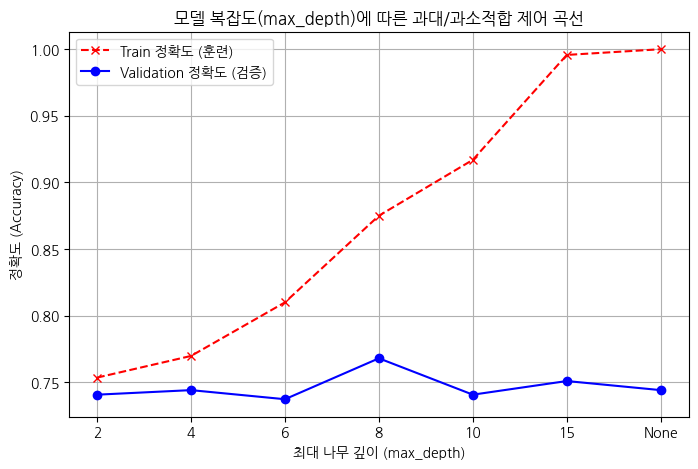

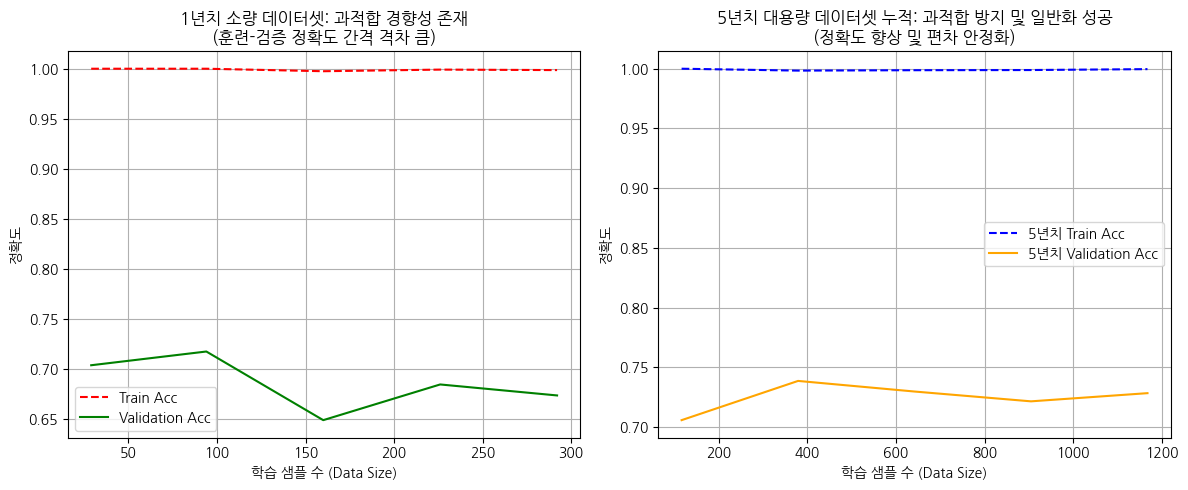

In [23]:
# 하이퍼파라미터 나무 깊이(max_depth) 변화에 따른 튜닝 실험
depths = [2, 4, 6, 8, 10, 15, None]
train_accuracies = []
val_accuracies = []

for d in depths:
    tune_model = RandomForestClassifier(n_estimators=50, max_depth=d, random_state=42)
    tune_model.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, tune_model.predict(X_train_scaled)))
    val_accuracies.append(accuracy_score(y_test, tune_model.predict(X_test_scaled)))

# 튜닝 커브 시각화
plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in depths], train_accuracies, 'x--', color='red', label='Train 정확도 (훈련)')
plt.plot([str(d) for d in depths], val_accuracies, 'o-', color='blue', label='Validation 정확도 (검증)')
plt.title('모델 복잡도(max_depth)에 따른 과대/과소적합 제어 곡선')
plt.xlabel('최대 나무 깊이 (max_depth)')
plt.ylabel('정확도 (Accuracy)')
plt.grid(True)
plt.legend()
plt.show()

# 1년치 실제 데이터와 5년치 실제 데이터셋 성능 향상 지표 비교 분석

# 1년치 데이터 실제 로드 및 전처리 (5년치와 동일한 방식 적용)
df_1yr = pd.read_csv('/content/기상데이터셋(1년치).csv', encoding='cp949')

df_1yr['일강수량(mm)'] = df_1yr['일강수량(mm)'].fillna(0.0)
df_1yr['내일강수량'] = df_1yr['일강수량(mm)'].shift(-1)
df_1yr['Target_Rain'] = df_1yr['내일강수량'].apply(lambda x: 1 if x > 0 else 0)
df_1yr_cleaned = df_1yr.dropna(subset=['내일강수량']).copy()

X_1yr = df_1yr_cleaned[selected_features]
y_1yr = df_1yr_cleaned['Target_Rain']

scaler_1yr = StandardScaler()
X_1yr_scaled = scaler_1yr.fit_transform(X_1yr)

# 과적합 상황을 유도하여 데이터 볼륨의 효과를 보기 위한 모델 정의
lc_model = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42)

# 1년치 데이터 학습 곡선 추출 (새로 불러온 X_1yr_scaled 사용)
train_sizes_1, train_scores_1, test_scores_1 = learning_curve(
    lc_model, X_1yr_scaled, y_1yr, cv=5, train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

# 5년치 데이터 학습 곡선 추출 (기존 메모리에 있는 X_scaled_all, y 활용)
train_sizes_5, train_scores_5, test_scores_5 = learning_curve(
    lc_model, X_scaled_all, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

# 시각화 비교
plt.figure(figsize=(12, 5))

# [좌측] 1년치 실제 데이터 학습 곡선
plt.subplot(1, 2, 1)
plt.plot(train_sizes_1, np.mean(train_scores_1, axis=1), 'r--', label='Train Acc')
plt.plot(train_sizes_1, np.mean(test_scores_1, axis=1), 'g-', label='Validation Acc')
plt.title('1년치 소량 데이터셋: 과적합 경향성 존재\n(훈련-검증 정확도 간격 격차 큼)')
plt.xlabel('학습 샘플 수 (Data Size)')
plt.ylabel('정확도')
plt.grid(True)
plt.legend()

# [우측] 5년치 실제 데이터 학습 곡선
plt.subplot(1, 2, 2)
plt.plot(train_sizes_5, np.mean(train_scores_5, axis=1), 'b--', label='5년치 Train Acc')
plt.plot(train_sizes_5, np.mean(test_scores_5, axis=1), 'orange', label='5년치 Validation Acc')
plt.title('5년치 대용량 데이터셋 누적: 과적합 방지 및 일반화 성공\n(정확도 향상 및 편차 안정화)')
plt.xlabel('학습 샘플 수 (Data Size)')
plt.ylabel('정확도')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 4. 최종 예측 결과 분석 및 기여도 출력
모델이 도출한 혼동 행렬(Confusion Matrix)과 상세 정밀도(Precision), 재현율(Recall) 지표 및 기상 특성별 중요도를 확인

=== 최종 성능 평가 레포트 ===
              precision    recall  f1-score   support

     비 안옴(0)       0.75      0.92      0.83       197
      비 옴(1)       0.71      0.38      0.49        96

    accuracy                           0.74       293
   macro avg       0.73      0.65      0.66       293
weighted avg       0.74      0.74      0.72       293



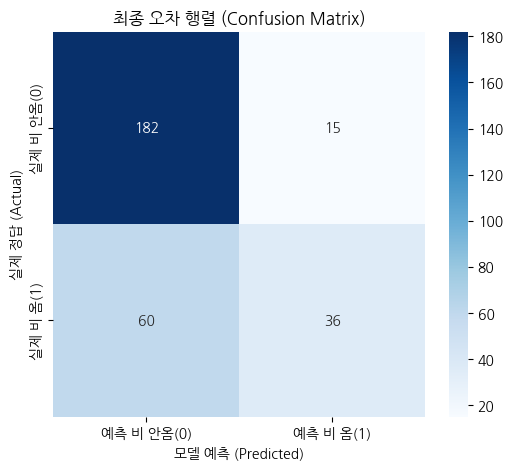

/tmp/ipykernel_2786/2908983263.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[selected_features[i] for i in indices], palette='mako')


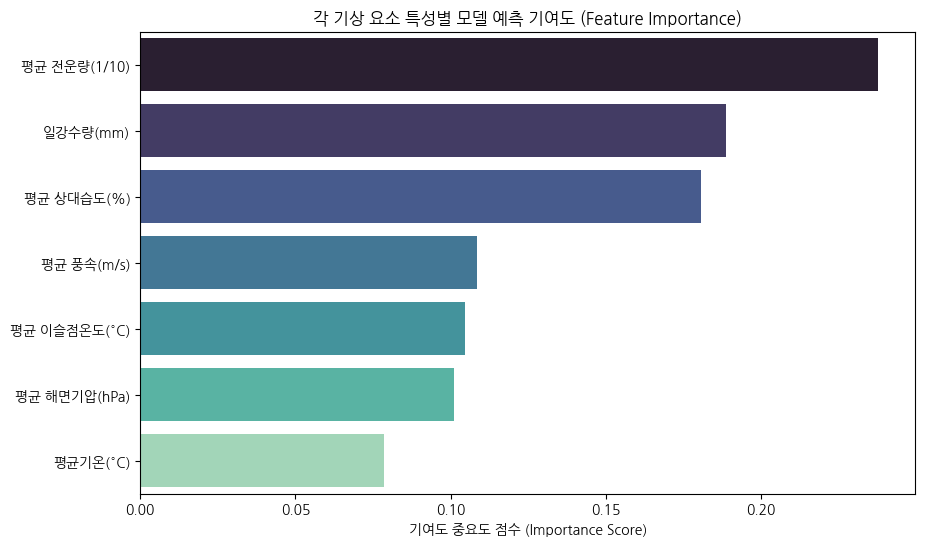

In [11]:
y_pred = rain_model.predict(X_test_scaled)

print('=== 최종 성능 평가 레포트 ===')
print(classification_report(y_test, y_pred, target_names=['비 안옴(0)', '비 옴(1)']))

# 혼동 행렬 오차행렬 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측 비 안옴(0)', '예측 비 옴(1)'],
            yticklabels=['실제 비 안옴(0)', '실제 비 옴(1)'])
plt.title('최종 오차 행렬 (Confusion Matrix)')
plt.ylabel('실제 정답 (Actual)')
plt.xlabel('모델 예측 (Predicted)')
plt.show()

# 특성 기여도(Feature Importance) 분석
importances = rain_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[selected_features[i] for i in indices], palette='mako')
plt.title('각 기상 요소 특성별 모델 예측 기여도 (Feature Importance)')
plt.xlabel('기여도 중요도 점수 (Importance Score)')
plt.show()

## 5. 실시간 내일 강수 여부 및 확률 예측 시뮬레이션 서비스
오늘 관측된 7가지 기상 요소를 입력하면 내일 비가 올 확률을 예측

In [26]:
def predict_tomorrow_rain_probability(today_data_list):
    """
    오늘의 날씨 제원을 입력받아 내일 강수 확률 백분율(%)을 리턴하는 서비스 함수
    입력 가이드: ['평균기온', '평균풍속', '평균이슬점', '평균습도', '평균해면기압', '평균전운량', '일강수량']
    """
    today_arr = np.array([today_data_list])
    today_scaled = scaler.transform(today_arr)

    # 확률 추정값 도출 (predict_proba)
    probabilities = rain_model.predict_proba(today_scaled)[0]
    no_rain_prob = probabilities[0] * 100
    rain_prob = probabilities[1] * 100

    print('=========================================')
    print(' [순천지역 내일 강수 예측 시뮬레이션 시스템] ')
    print('=========================================')
    print(f'-> 내일 비가 올 확률   : {rain_prob:.2f}%')
    if rain_prob >= 50.0:
        print(f'강수 확률이 {rain_prob:.2f}%로 우세합니다. 우산을 지참하세요!')
    else:
        print(f'강수 확률이 {rain_prob:.2f}%로 낮습니다. 맑거나 흐린 기후가 예상됩니다.')
    print('=========================================')

# 예시 오늘 데이터 검증 테스트 실행
# 사용방법: [기온, 풍속, 이슬점온도, 상대습도, 해면기압, 전운량, 오늘강수량] (사용자가 임의 입력)
sample_today_weather = [18.2, 2.5, 17.5, 95.0, 1004.2, 9.5, 8.5]
predict_tomorrow_rain_probability(sample_today_weather)

 [순천지역 내일 강수 예측 시뮬레이션 시스템] 
-> 내일 비가 올 확률   : 77.92%
강수 확률이 77.92%로 우세합니다. 우산을 지참하세요!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
